# Facial Emotion Recognition System - Clean Version with Live Video

This notebook provides a complete facial emotion recognition system using Vision Transformer (ViT) model.

## Overview
- Detects faces in video frames
- Recognizes 7 emotions: anger, disgust, fear, happy, neutral, sad, surprise
- Live video window with real-time emotion overlays (only local support not in colab remote server)
- Provides optimized versions for both CPU and GPU
- Generates detailed reports and visualizations

---

## 1. Install Required Dependencies

Install all necessary libraries for the emotion detection system.

In [1]:
!pip install transformers torch opencv-python pillow pandas matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Import Libraries

Import all required libraries for video processing, model inference, and visualization.

In [2]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoModelForImageClassification, AutoImageProcessor
import torch
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
from collections import deque
import time
import warnings
warnings.filterwarnings('ignore')

c:\emotion detection module pckg\emotion_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Emotion Detection Class with Live Video Support

This class handles:
- Loading the ViT emotion recognition model
- Face detection and cropping
- **Real-time video display with emotion overlays**
- Batch processing of video frames
- Emotion analysis and reporting

**NEW FEATURES:**
- ✅ Live video window (Jupyter Notebook only)
- ✅ Real-time emotion percentages on video
- ✅ Save processed video option
- ✅ Press 'q' to quit early

In [3]:
class EmotionDetectorCPU:
    """
    CPU-optimized emotion detector with live video display support.
    """

    def __init__(self, model_path):
        print("=" * 60)
        print("INITIALIZING EMOTION DETECTOR (CPU MODE)")
        print("=" * 60)

        self.device = torch.device("cpu")
        torch.set_num_threads(4)
        print(f"✓ Device: {self.device} with {torch.get_num_threads()} threads")

        print(f"✓ Loading model from: {model_path}")
        self.model = AutoModelForImageClassification.from_pretrained(model_path).to(self.device)
        self.image_processor = AutoImageProcessor.from_pretrained(model_path)
        self.model.eval()
        print("✓ Model loaded successfully")

        # Processing parameters
        self.frame_width = 640
        self.frame_height = 640
        self.batch_size = 1  # Process one frame at a time for live display
        self.fps_target = 25

        # Emotion weights
        self.emotion_weights = {
            'anger': 3.1,
            'disgust': 0.8,
            'fear': 1.2,
            'happy': 0.5,
            'neutral': 0.4,
            'sad': 1.1,
            'surprise': 0.5
        }

        # Initialize face detector
        self.face_detector = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )
        print("✓ Face detector initialized")
        print("=" * 60)
        print()

    def detect_and_crop_face(self, frame):
        """Detect largest face and crop with padding."""
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = self.face_detector.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=4, minSize=(30, 30))

        if len(faces) == 0:
            return cv2.resize(frame, (self.frame_width, self.frame_height))

        largest_face = max(faces, key=lambda x: x[2] * x[3])
        x, y, w, h = largest_face

        padding = int(0.2 * max(w, h))
        x = max(0, x - padding)
        y = max(0, y - padding)
        w = min(frame.shape[1] - x, w + 2 * padding)
        h = min(frame.shape[0] - y, h + 2 * padding)

        face_img = frame[y:y+h, x:x+w]
        return cv2.resize(face_img, (self.frame_width, self.frame_height))

    def process_single_frame(self, frame):
        """Process a single frame and return emotion scores."""
        pil_image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        with torch.no_grad():
            inputs = self.image_processor([pil_image], return_tensors="pt")
            outputs = self.model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

        predictions = probs.numpy()[0]
        emotion_scores = {
            emotion: float(prob)
            for emotion, prob in zip(self.model.config.id2label.values(), predictions)
        }

        # Handle angry/anger label
        if 'angry' in emotion_scores:
            emotion_scores['anger'] = emotion_scores.pop('angry')

        # Apply weights
        weighted_scores = {
            emotion: score * self.emotion_weights.get(emotion, 1.0)
            for emotion, score in emotion_scores.items()
        }

        return weighted_scores

    def draw_emotion_overlay(self, frame, percentage_scores, frame_count):
        """Draw emotion scores on the frame."""
        # Title
        cv2.putText(frame, f"Frame {frame_count}", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        # Emotion scores
        y_offset = 70
        for emotion, score in sorted(percentage_scores.items(), key=lambda x: x[1], reverse=True):
            text = f"{emotion.capitalize()}: {score:.2f}%"
            cv2.putText(frame, text, (10, y_offset),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
            y_offset += 35

        return frame

    def process_video_with_display(self, video_path, show_live=True, save_video=False, output_path="output.mp4"):
        """
        Process video with optional live display and/or save output.

        Args:
            video_path: Input video path
            show_live: Show live video window (only works in Jupyter locally, not Colab)
            save_video: Save processed video with overlays
            output_path: Output video file path
        """
        print("=" * 60)
        print("STARTING VIDEO PROCESSING WITH LIVE DISPLAY")
        print("=" * 60)

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError(f"Error: Could not open video: {video_path}")

        # Get video properties
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))

        print(f"Video Info:")
        print(f"  - Total frames: {total_frames}")
        print(f"  - FPS: {fps}")
        print(f"  - Live display: {'ON' if show_live else 'OFF'}")
        print(f"  - Save video: {'ON' if save_video else 'OFF'}")
        if show_live:
            print(f"  - Press 'q' to quit early")
        print()

        # Initialize video writer if saving
        video_writer = None
        if save_video:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            video_writer = cv2.VideoWriter(output_path, fourcc, fps,
                                          (self.frame_width, self.frame_height))
            print(f"✓ Saving to: {output_path}")

        # Processing variables
        results = []
        emotion_window = deque(maxlen=5)  # Sliding window for smoothing
        frame_count = 0
        start_time = time.time()

        # Process video
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_count += 1

            # Resize frame
            frame_resized = cv2.resize(frame, (self.frame_width, self.frame_height))

            # Detect and crop face
            processed_frame = self.detect_and_crop_face(frame)

            # Get emotion predictions
            weighted_scores = self.process_single_frame(processed_frame)

            # Apply sliding window smoothing
            emotion_window.append(weighted_scores)
            avg_scores = {
                emotion: np.mean([window[emotion] for window in emotion_window])
                for emotion in weighted_scores
            }

            # Store results
            results.append((frame_count, avg_scores))

            # Calculate percentages
            total_score = sum(avg_scores.values())
            percentage_scores = {
                emotion: (score / total_score) * 100 if total_score > 0 else 0.0
                for emotion, score in avg_scores.items()
            }

            # Draw overlays on original frame
            display_frame = frame_resized.copy()
            display_frame = self.draw_emotion_overlay(display_frame, percentage_scores, frame_count)

            # Save frame if requested
            if save_video:
                video_writer.write(display_frame)

            # Display live window if requested
            if show_live:
                cv2.imshow('Emotion Detection - Press Q to Quit', display_frame)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    print("\n⚠ Stopped by user")
                    break

            # Progress update
            if frame_count % 30 == 0:
                progress = (frame_count / total_frames) * 100
                elapsed = time.time() - start_time
                fps_current = frame_count / elapsed
                remaining = (total_frames - frame_count) / fps_current if fps_current > 0 else 0
                print(f"\rProgress: {progress:.1f}% | FPS: {fps_current:.1f} | Remaining: {remaining:.1f}s",
                      end="", flush=True)

        # Cleanup
        cap.release()
        if video_writer:
            video_writer.release()
        if show_live:
            cv2.destroyAllWindows()

        print("\n\n✓ Processing complete!")
        if save_video:
            print(f"✓ Video saved to: {output_path}")
        print("=" * 60)
        print()

        return self._analyze_results(results)

    def _analyze_results(self, results):
        """Analyze emotion detection results and generate reports."""
        print("=" * 60)
        print("ANALYZING RESULTS")
        print("=" * 60)

        emotion_totals = {}
        for _, scores in results:
            for emotion, score in scores.items():
                emotion_totals[emotion] = emotion_totals.get(emotion, 0) + score

        total_frames = len(results)
        avg_emotions = {emotion: score/total_frames for emotion, score in emotion_totals.items()}

        df = pd.DataFrame([(idx, scores) for idx, scores in results],
                         columns=['Frame', 'Emotion Scores'])

        plt.figure(figsize=(12, 6))
        emotions = list(avg_emotions.keys())
        scores = list(avg_emotions.values())

        bars = plt.bar(emotions, scores, color='skyblue', edgecolor='navy', linewidth=1.5)
        plt.xlabel('Emotions', fontsize=12, fontweight='bold')
        plt.ylabel('Average Weighted Score', fontsize=12, fontweight='bold')
        plt.title('Emotion Analysis Results', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()

        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=9)

        print("✓ Analysis complete")
        print("=" * 60)
        print()

        return {
            'average_emotions': avg_emotions,
            'dominant_emotion': max(avg_emotions.items(), key=lambda x: x[1])[0],
            'detailed_report': df,
            'plot': plt
        }

    def save_results(self, results, output_prefix="emotion_analysis"):
        """Save analysis results to files."""
        print("=" * 60)
        print("SAVING RESULTS")
        print("=" * 60)

        csv_path = f"{output_prefix}_report.csv"
        results['detailed_report'].to_csv(csv_path, index=False)
        print(f"✓ CSV report saved: {csv_path}")

        plot_path = f"{output_prefix}_plot.png"
        results['plot'].savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"✓ Plot saved: {plot_path}")

        print("=" * 60)
        print()

## 4. Configuration & Setup

**IMPORTANT: Update these paths before running!**

In [4]:
# =====================================================================
# CONFIGURATION - UPDATE THESE PATHS
# =====================================================================

# Path to your fine-tuned ViT emotion model
MODEL_PATH = "vit-Facial-Expression-Recognition"

# Or use HuggingFace model:
# MODEL_PATH = "motheecreator/vit-Facial-Expression-Recognition"

# Input video path
VIDEO_PATH = "test_data\8627839-hd_1080_1920_25fps.mp4"

# Output prefix for CSV and plot
OUTPUT_PREFIX = "emotion_analysis"

# =====================================================================
# DISPLAY OPTIONS
# =====================================================================

# Show live video window with emotion overlays
# Works in: Jupyter Notebook (local), VS Code, PyCharm
# Does NOT work in: Google Colab, Kaggle Notebooks
SHOW_LIVE_VIDEO = True  # Set to False for Colab

# Save processed video with emotion overlays to file
SAVE_OUTPUT_VIDEO = False  # Set to True to save video
OUTPUT_VIDEO_PATH = "emotion_detected_video.mp4"

# =====================================================================

## 5. Run Emotion Analysis with Live Video

This will:
1. **Show live video window** (if SHOW_LIVE_VIDEO=True and running locally)
2. Display real-time emotion percentages on each frame
3. Allow you to press 'q' to stop early
4. Generate final emotion analysis
5. Save reports to disk

**Note:** Live video window only works in Jupyter Notebook running locally. For Google Colab, set `SHOW_LIVE_VIDEO = False` and `SAVE_OUTPUT_VIDEO = True` instead.

INITIALIZING EMOTION DETECTOR (CPU MODE)
✓ Device: cpu with 4 threads
✓ Loading model from: vit-Facial-Expression-Recognition


Loading weights: 100%|██████████| 200/200 [00:01<00:00, 134.70it/s, Materializing param=vit.layernorm.weight]                                 


✓ Model loaded successfully
✓ Face detector initialized

STARTING VIDEO PROCESSING WITH LIVE DISPLAY
Video Info:
  - Total frames: 298
  - FPS: 25
  - Live display: ON
  - Save video: OFF
  - Press 'q' to quit early

Progress: 90.6% | FPS: 1.4 | Remaining: 20.4ss

✓ Processing complete!

ANALYZING RESULTS
✓ Analysis complete

FINAL RESULTS

🎯 Dominant Emotion: SURPRISE

📊 Average Emotion Scores (Weighted):
----------------------------------------
  Surprise    : 0.2266
  Sad         : 0.1912
  Fear        : 0.1219
  Disgust     : 0.1000
  Neutral     : 0.0545
  Anger       : 0.0137
  Happy       : 0.0029

SAVING RESULTS
✓ CSV report saved: emotion_analysis_report.csv
✓ Plot saved: emotion_analysis_plot.png



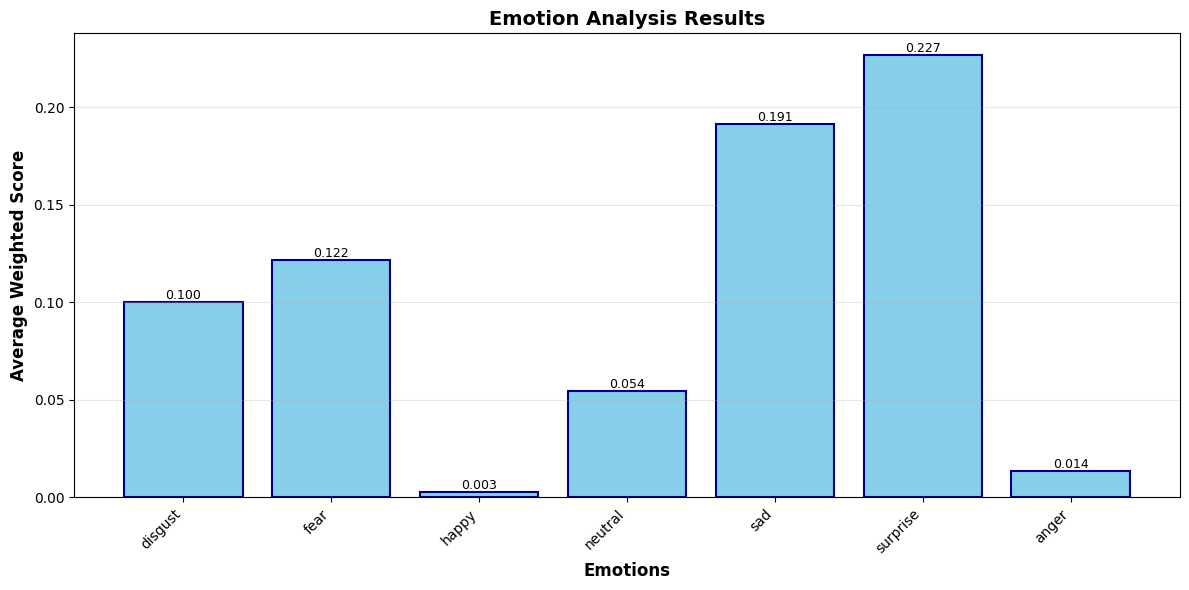

In [5]:
# Initialize detector
detector = EmotionDetectorCPU(MODEL_PATH)

# Process video with live display
results = detector.process_video_with_display(
    video_path=VIDEO_PATH,
    show_live=SHOW_LIVE_VIDEO,
    save_video=SAVE_OUTPUT_VIDEO,
    output_path=OUTPUT_VIDEO_PATH
)

# Display final results
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)
print(f"\n🎯 Dominant Emotion: {results['dominant_emotion'].upper()}")
print("\n📊 Average Emotion Scores (Weighted):")
print("-" * 40)
for emotion, score in sorted(results['average_emotions'].items(), key=lambda x: x[1], reverse=True):
    print(f"  {emotion.capitalize():<12}: {score:.4f}")
print("=" * 60)
print()

# Save results
detector.save_results(results, OUTPUT_PREFIX)

# Show plot
plt.show()

## 6. Understanding the Live Video Feature

### What You See in the Live Window:
- **Frame number** at the top
- **Real-time emotion percentages** sorted by score
- **Smoothed predictions** using 5-frame sliding window
- **Face detection** applied automatically

### Controls:
- Press **'q'** to quit early
- Window closes automatically when video ends

### Environment Compatibility:

| Environment | Live Window | Workaround |
|-------------|-------------|------------|
| Jupyter (Local) | Works   |    - |
| VS Code | Works | - |
| PyCharm | Works | - |
| Google Colab | No GUI | Set `SAVE_OUTPUT_VIDEO=True` |
| Kaggle Notebooks | No GUI | Set `SAVE_OUTPUT_VIDEO=True` |

### For Google Colab Users:
```python
# Use these settings instead:
SHOW_LIVE_VIDEO = False
SAVE_OUTPUT_VIDEO = True

# After processing, download the video:
from google.colab import files
files.download('emotion_detected_video.mp4')
```

---

## Troubleshooting

**Issue: Window doesn't appear**
- Make sure you're running in Jupyter Notebook locally, not Colab
- Check that OpenCV is installed: `pip install opencv-python`

**Issue: "Unable to open video"**
- Verify VIDEO_PATH is correct
- Ensure video codec is supported (try .mp4 or .avi)

**Issue: Slow processing**
- Normal for CPU processing
- Consider using shorter video for testing
- GPU version would be faster